In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

cinema_audience_forecasting_challenge_path = kagglehub.competition_download('Cinema_Audience_Forecasting_challenge')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [ ]:
# Load booknow booking data and check missing values
booknow_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')

# Load booknow theaters data and check missing values
booknow_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')

# Load booknow visits data and check missing values
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')

# Load cinePOS booking data and check missing values
cinepos_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')

# Load cinePOS theaters data and check missing values
cinepos_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')

# Load date info data and check missing values
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')

# Load theater-movie ID relation data and check missing values
id_relation = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')

sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

### Milestone 01 Code:

In [ ]:
'''
# Milestone 01

# ------------------ Q 01) --------------------------------
# 01 What is the shape of the dataset named booknow_booking?
print("01) Shape of booknow_booking :",booknow_booking.shape)

# ------------------ Q 02) --------------------------------
# 02 How many columns are of type Object in the dataset named cinePOS_theaters?
obj_column = cinepos_theaters.select_dtypes(include='object').columns
print("02) count of Object columns in cinpos_theaters",len(obj_column))

# ------------------ Q 03) --------------------------------
# 03 Which of the following theater types is the most frequent in the dataset named booknow_theaters?
theater_count = booknow_theaters['theater_type'].value_counts()
print("03) Theater coun:",theater_count)

# ------------------ Q 04) --------------------------------
# 04 How many distinct theaters are present in the dataset named cinePOS_booking?
theater_count = cinepos_booking['cine_theater_id'].nunique()
print("04) distinct theater count in cinpos_booking: ",theater_count)

# ------------------ Q 05) --------------------------------
# 05 Combine the datasets booknow_booking and booknow_theaters. What is the shape of this dataset?
book_online = pd.merge(
    booknow_booking.copy(),        # <-- use a copy
    booknow_theaters.copy(),       # <-- use a copy
    on='book_theater_id',
    how='inner'
)
print("05) Shape of combined booknow booking + booknwo theaters: ",book_online.shape)

# ------------------ Q 06) --------------------------------
# 06 Based on the combined dataset obtained in the previous question, how many distinct areas are the theaters located in?
print(f"06) distinc areas {book_online['theater_area'].nunique()}")


# ------------------ Q 07) --------------------------------
# 07 Combine the datasets movie_theater_id_relation, cinePOS_booking and cinePOS_theaters. Enter the column names containing missing values as comma seperated values
merged_df = pd.merge(
    id_relation.copy(),
    cinepos_booking.copy(),
    on="cine_theater_id",
    how = "inner"
)

merged_df = pd.merge(
    merged_df,
    cinepos_theaters.copy(),
    on ="cine_theater_id",
    how = "inner"
)
print("07)")
print("null %:\n",merged_df.isnull().sum() /len(merged_df) * 100)
print("unique ids:", merged_df['cine_theater_id'].nunique())
print("shape:", merged_df.shape)

# ------------------ Q 08) --------------------------------
# 08 Enter the date range spanned in the dataset named booknow_booking.
booknow_booking["show_datetime"] = pd.to_datetime(booknow_booking["show_datetime"])
booknow_booking["booking_datetime"] = pd.to_datetime(booknow_booking["booking_datetime"])

# Find overall min and max
earliest_show = booknow_booking["show_datetime"].min()
earliest_book = booknow_booking["booking_datetime"].min()

latest_show = booknow_booking["show_datetime"].max()
latest_book = booknow_booking["booking_datetime"].max()
print("08)")
print("earliest_show : ", earliest_show)
print("latest_show", latest_show)
print("earliest_book",earliest_book)
print("latest_book",latest_book)

# ------------------ Q 09) --------------------------------
# 09 Enter the date range spanned in the test dataset (sample_submission).
sample_sub = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
sample_sub_cpy = sample_sub.copy()
sample_sub_cpy["date_extracted"] = sample_sub_cpy["ID"].str.split("_").str[-1]
sample_sub_cpy["date_extracted"] = pd.to_datetime(sample_sub_cpy["date_extracted"])

earliest = sample_sub_cpy["date_extracted"].min()
latest   = sample_sub_cpy["date_extracted"].max()
print("09)")
print("earliest: ", earliest)
print("latest: ", latest)

del (theater_count,earliest,latest ,book_online,merged_df,
     earliest_show,earliest_book,latest_show,latest_book,
     sample_sub,sample_sub_cpy)
'''

### Milestone 02 Code:

In [ ]:
'''
# Milestone 2
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings("ignore")

# ------------------ Q 01) --------------------------------
# Q 01) In the booknow_booking.csv file, how many total booking records (rows) were made on the same calendar day as the show's date?
# Note: The question refers to day / date and not datetime
booknow_booking_cpy = booknow_booking.copy()
booknow_booking_cpy['show_date'] = pd.to_datetime(booknow_booking_cpy['show_datetime']).dt.date
booknow_booking_cpy['booking_date'] = pd.to_datetime(booknow_booking_cpy['booking_datetime']).dt.date
print("01: ",booknow_booking_cpy[booknow_booking_cpy['show_date'] == booknow_booking_cpy['booking_date']].shape[0])
# Ans: 20433

# ------------------ Q 02) --------------------------------
# Q 02) How many unique calendar months (e.g., Jan 2023, Feb 2023, ...) are present in the show_date column of the date_info.csv file?
date_info_cpy = date_info.copy()
date_info_cpy['show_date'] = pd.to_datetime(date_info_cpy['show_date'])
date_info_cpy['Year_Month'] = date_info_cpy['show_date'].dt.to_period('M')
print("02: ",date_info_cpy['Year_Month'].nunique())
# ans: 18

# ------------------ Q 03) --------------------------------
# Q 03) What percentage of bookings in booknow_booking.csv were made on a Sunday?
booknow_booking_cpy.drop_duplicates(inplace=True)
booknow_booking_cpy['booking_date'] = pd.to_datetime(booknow_booking_cpy['booking_datetime']).dt.date
date_info_cpy['show_date'] = pd.to_datetime(date_info_cpy['show_date']).dt.date
# Drop duplicate columns (if already exist in both)
common_cols = list(set(booknow_booking_cpy.columns) & set(date_info_cpy.columns))
common_cols.remove('show_date')  # keep 'show_date' for merge

booknow_booking_cpy = pd.merge(
    booknow_booking_cpy,
    date_info_cpy.drop(columns=common_cols),  # drop overlapping columns
    how='left',
    left_on='booking_date',
    right_on='show_date'
).drop(columns=['show_date_x','show_date_y'],axis=1)
booknow_booking_cpy.drop_duplicates(inplace=True)
per = booknow_booking_cpy[booknow_booking_cpy['day_of_week'] == 'Sunday'].shape[0] / len(booknow_booking_cpy) * 100
print(f"03: Sunday booking percentage : {per:.2f}")

# Ans: 13.32%

# ------------------ Q 04) --------------------------------
# Q 04) In the booknow_theaters.csv file, if you decided to impute any missing latitude values by the mean latitude of only theaters with theater_type equal to Drama, what would be the imputation value?
mean = booknow_theaters[booknow_theaters['theater_type'] == 'Drama']['latitude'].mean()
print(f"04: Latitude mean: {mean}")
# Ans: 23.000

# ------------------ Q 05) --------------------------------
# Q 05) What is the range (Maximum - Minimum) of the latitude column in the booknow_theaters.csv file (rounded to 4 decimal places)?
max_range = booknow_theaters['latitude'].max() - booknow_theaters['latitude'].min()
print(f"05: Range: {max_range}")
# Ans: 4.323

# ------------------ Q 06) --------------------------------
# Q 06) To handle potential outliers in ticket sales, you decide to cap the tickets_sold column in cinePOS_booking.csv at the 95 th  percentile. Enter that value.
print("06: 95th percentile: ",cinepos_booking['tickets_sold'].quantile(0.95))
# Ans: 14.0

# ------------------ Q 07) --------------------------------
# Q 07) Appy OneHot Encoding on all the categorical columns of the dataset cinePOS_theaters.csv. What is the shape of the dataset after applying this transformation?
# Note: The result obtained highlights a potential drawback of OneHot encoding. Read about other forms of encoding and the advantages / disadvantages they offer.
cinepos_theaters_cpy = cinepos_theaters.copy()
cat_col = cinepos_theaters_cpy.select_dtypes(include=['object', 'category']).columns.tolist()
ohc = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoded = ohc.fit_transform(cinepos_theaters_cpy[cat_col])
encoded_df = pd.DataFrame(
    encoded,
    index=cinepos_theaters_cpy.index,
    columns=ohc.get_feature_names_out(cat_col)
)
cinepos_theaters_cpy = pd.concat(
    [cinepos_theaters_cpy.drop(columns=cat_col), encoded_df],
    axis=1
)
print("07: Shape after encoding: ",cinepos_theaters_cpy.shape)
# Ans: (4690, 4814)

del (
    booknow_booking_cpy,date_info_cpy,per,mean,max_range,cinepos_theaters_cpy,
    cat_col,ohc,encoded,encoded_df,
)
'''

### Milestone 03 Code:

In [ ]:
'''
# Milestone 03

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# ------------------ Q 01) --------------------------------
df = booknow_visits.copy()
df['show_date'] = pd.to_datetime(df['show_date'])
df['day'] = df['show_date'].dt.day
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year
df['dayofyear'] = df['show_date'].dt.dayofyear
df.drop(columns=['show_date'], inplace=True)
X = df.drop(columns=['audience_count'])
y = df['audience_count']
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
print("01) x train shape: ",X_train.shape)

# ------------------ Q 02) --------------------------------
# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
model = Pipeline([
    ('prep', preprocessor),
    ('svr', LinearSVR(random_state=0))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("02) R² score on test data:", round(r2, 3))

# ------------------ Q 03) --------------------------------
model = Pipeline([
    ('prep', preprocessor),
    ('svd', TruncatedSVD(n_components=4, random_state=0)),
    ('svr', LinearSVR(random_state=0))
])
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
mae = mean_absolute_error(y_train, y_train_pred)
print("03) Mean Absolute Error on training data:", round(mae, 3))

# ------------------ Q 04) --------------------------------
y_test_pred = model.predict(X_test)
r2 = r2_score(y_test, y_test_pred)
print("04) R² score on test data:", round(r2, 3))

# ------------------ Q 05) --------------------------------
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)
selector = SelectKBest(score_func=mutual_info_regression, k=2)
selector.fit(X_train_trans, y_train)
max_score = selector.scores_.max()
print("05) Maximum score from SelectKBest:", round(max_score, 3))

# ------------------ Q 06) --------------------------------
mean_score = selector.scores_.mean()
print("06) Mean value of SelectKBest scores:", round(mean_score, 3))
'''

### Milestone 04 Code:

In [ ]:
'''
# Milestone 4

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error


# ------------------ Q 01) --------------------------------
df = booknow_visits
df['show_date'] = pd.to_datetime(df['show_date'])
df['day'] = df['show_date'].dt.day
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year
df['dayofyear'] = df['show_date'].dt.dayofyear
df = df.drop(columns=['show_date'])
X = df.drop(columns=['audience_count'])
y = df['audience_count']
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
# Identify columns
num_cols = ['day', 'month', 'year', 'dayofyear']
cat_cols = ['book_theater_id']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
model = Pipeline([
    ('prep', preprocessor),
    ('dt', DecisionTreeRegressor())
])
model.fit(X_train, y_train)
train_preds = model.predict(X_train)
train_r2 = r2_score(y_train, train_preds)
print("01) R2 Score on X_train:", round(train_r2, 3))

# ------------------ Q 02) --------------------------------
test_preds = model.predict(X_test)
test_r2 = r2_score(y_test, test_preds)
print("02) R2 Score on X_test:", round(test_r2, 3))

# ------------------ Q 03) --------------------------------
tscv = TimeSeriesSplit(n_splits=5)
dt = DecisionTreeRegressor(random_state=42)
param_grid = {
    'dt__max_depth': [None, 3, 5, 10],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("03) Best Parameters:", grid_search.best_params_)

# ------------------ Q 04) --------------------------------
bag_model = Pipeline([
    ('prep', preprocessor),
    ('bag', BaggingRegressor())
bag_model.fit(X_train, y_train)
train_preds_bag = bag_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds_bag))
print("04) Train RMSE:", round(rmse_trian, 3)

# ------------------ Q 05) --------------------------------
test_preds_bag = bag_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds_bag))
print("05) Test RMSE:", round(rmse_test, 3))

# ------------------ Q 06) --------------------------------
tscv = TimeSeriesSplit(n_splits=5)
bag = BaggingRegressor(random_state=42)
pipe_bag = Pipeline([
    ("prep", preprocessor),
    ("bag", bag)
])
param_grid = {
    "bag__n_estimators": [10, 50, 100],
    "bag__max_samples": [0.5, 0.7, 1.0],
    "bag__max_features": [0.5, 0.8, 1.0]
}
grid_bag = GridSearchCV(
    estimator=pipe_bag,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_bag.fit(X_train, y_train)
best_score_rmse = -grid_bag.best_score_
print("06) Best Score (RMSE):", round(best_score_rmse, 3))

# ------------------ Q 07) --------------------------------
gbr_model = Pipeline([
    ('prep', preprocessor),
    ('gbr', GradientBoostingRegressor())
])
gbr_model.fit(X_train, y_train)
train_preds_gbr = gbr_model.predict(X_train)
mae_train = mean_absolute_error(y_train, train_preds_gbr)
print("07) Train MAE:", round(mae_train, 3))

# ------------------ Q 08) --------------------------------
test_preds_gbr = gbr_model.predict(X_test)
mae_test = mean_absolute_error(y_test, test_preds_gbr)
print("08) Test MAE:", round(mae_test, 3))
'''

### Milestone 05 Code:

In [ ]:
'''
# Milestone 05

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')

bn_bookings = booknow_booking.copy()
cp_bookings = cinePOS_booking.copy()
theater_link = id_relation.copy()
bn_visits = booknow_visits.copy()

# ------------------ Q 01) --------------------------------
bn_daily = bn_bookings.copy()
bn_daily['show_date'] = pd.to_datetime(bn_daily['show_datetime']).dt.date
bn_daily = bn_daily.groupby(['book_theater_id', 'show_date'])['tickets_booked'].sum().reset_index()
print(f"01) Shape of bn_daily: {bn_daily.shape}")

# ------------------ Q 02) --------------------------------
cp_daily = cp_bookings.copy()
cp_daily['show_date'] = pd.to_datetime(cp_daily['show_datetime']).dt.date
cp_daily = cp_daily.groupby(['cine_theater_id', 'show_date'])['tickets_sold'].sum().reset_index()
print(f"02) Shape of cp_daily: {cp_daily.shape}")

# ------------------ Q 03) --------------------------------
bn_daily['show_date'] = pd.to_datetime(bn_daily['show_date'])
cp_daily['show_date'] = pd.to_datetime(cp_daily['show_date'])
cp_with_bookid = pd.merge(theater_link, cp_daily, on='cine_theater_id')
merged_bookings = pd.merge(
    bn_daily,
    cp_with_bookid[['book_theater_id', 'show_date', 'tickets_sold']],
    on=['book_theater_id', 'show_date'],
    how='outer'
)
print(f"03) Shape of merged_bookings: {merged_bookings.shape}")

# ------------------ Q 04) --------------------------------
bn_visits['show_date'] = pd.to_datetime(bn_visits['show_date'])
final_df = pd.merge(
    bn_visits,
    merged_bookings,
    on=['book_theater_id', 'show_date'],
    how='left'
)
final_df = final_df.sort_values(by=['book_theater_id', 'show_date'])
final_df['audience_prev_day'] = final_df.groupby('book_theater_id')['audience_count'].shift(1)
null_lags = final_df['audience_prev_day'].isnull().sum()
print(f"04) Missing values in 'audience_prev_day': {null_lags}")

# ------------------ Q 05) --------------------------------
series_data = bn_visits[bn_visits['book_theater_id'] == 'book_00001']
series_data = series_data.set_index('show_date')['audience_count'].sort_index()
adf_outcome = adfuller(series_data)
p_val = adf_outcome[1]
print(f"05) ADF p-value for 'book_00001': {p_val:.6f}")

# ------------------ Q 06) --------------------------------
if p_val <= 0.05:
    print("06) Conclusion: Stationary")
else:
    print("06) Conclusion: Not stationary")

# ------------------ Q 07) --------------------------------
train_series = series_data.iloc[:-30]
test_series = series_data.iloc[-30:]
print(f"07) Records in training data: {len(train_series)}")

# ------------------ Q 08) --------------------------------
print("08) Chosen ARIMA(1,1,1), so differencing parameter (d) = 1")

# ------------------ Q 09) --------------------------------
arima_model = ARIMA(train_series, order=(1, 1, 1))
fitted_model = arima_model.fit()
print(f"09) AIC of the fitted model: {fitted_model.aic:.3f}")

# ------------------ Q 10) --------------------------------
forecast_values = fitted_model.forecast(steps=len(test_series))
r2_val = r2_score(test_series, forecast_values)
print(f"10) R² on test set: {r2_val:.3f}")
'''

# 1. EDA on Raw Data

#### ●  Finding missing values in all CSV

In [ ]:
print("Missing values in booknow_booking:")
print(booknow_booking.isnull().sum())

print("\nMissing values in booknow_theaters:")
print(booknow_theaters.isnull().sum())

print("\nMissing values in booknow_visits:")
print(booknow_visits.isnull().sum())

print("\nMissing values in cinepos_booking:")
print(cinepos_booking.isnull().sum())

print("\nMissing values in cinepos_theaters:")
print(cinepos_theaters.isnull().sum())

print("\nMissing values in date_info:")
print(date_info.isnull().sum())

print("\nMissing values in id_relation:")
print(id_relation.isnull().sum())

Missing values in booknow_booking:
book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64

Missing values in booknow_theaters:
book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64

Missing values in booknow_visits:
book_theater_id    0
show_date          0
audience_count     0
dtype: int64

Missing values in cinepos_booking:
cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64

Missing values in cinepos_theaters:
cine_theater_id       0
theater_type          0
theater_area          0
latitude           3861
longitude          3861
dtype: int64

Missing values in date_info:
show_date      0
day_of_week    0
dtype: int64

Missing values in id_relation:
book_theater_id    0
cine_theater_id    0
dtype: int64


#### ●  Finding unique IDs in all CSV

In [ ]:
# Unique IDs in BookNow datasets
print("Unique theater IDs in booknow_booking:", booknow_booking['book_theater_id'].nunique())
print("Unique theater IDs in booknow_theaters:", booknow_theaters['book_theater_id'].nunique())
print("Unique theater IDs in booknow_visits:", booknow_visits['book_theater_id'].nunique())

# Unique IDs in CinePOS datasets
print("Unique theater IDs in cinepos_booking:", cinepos_booking['cine_theater_id'].nunique())
print("Unique theater IDs in cinepos_theaters:", cinepos_theaters['cine_theater_id'].nunique())

print("\n--- ID Relation File ---")
# Unique IDs in the relation mapping file
print("Unique cine_theater_id in id_relation:", id_relation['cine_theater_id'].nunique())
print("Unique book_theater_id in id_relation:", id_relation['book_theater_id'].nunique())

Unique theater IDs in booknow_booking: 301
Unique theater IDs in booknow_theaters: 314
Unique theater IDs in booknow_visits: 826
Unique theater IDs in cinepos_booking: 13161
Unique theater IDs in cinepos_theaters: 4690

--- ID Relation File ---
Unique cine_theater_id in id_relation: 150
Unique book_theater_id in id_relation: 150


#### ●  Finding the min–max date range in all CSVs

In [ ]:
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
print("booknow_booking min date:",booknow_booking['show_datetime'].min())
print("booknow_booking max date:",booknow_booking['show_datetime'].max())
print('\n')

booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
print("booknow_visits min date:",booknow_visits['show_date'].min())
print("booknow_visits max date:",booknow_visits['show_date'].max())
print('\n')

cinepos_booking['show_datetime'] = pd.to_datetime(cinepos_booking['show_datetime'])
print("cinepos_booking min date:",cinepos_booking['show_datetime'].min())
print("cinepos_booking max date:",cinepos_booking['show_datetime'].max())
print('\n')

date_info['show_date'] = pd.to_datetime(date_info['show_date'])
print("date_info min date:",date_info['show_date'].min())
print("date_info max date:",date_info['show_date'].max())
print('\n')

sample_sub = sample_submission.copy()
sample_sub[['book_theater_id', 'show_date']] = sample_sub['ID'].str.rsplit('_', n=1, expand=True)
sample_sub['show_date'] =  pd.to_datetime(sample_sub['show_date'])
print("sample_submission min date:",sample_sub['show_date'].min())
print("sample_submission max date:",sample_sub['show_date'].max())

booknow_booking min date: 2023-01-01 19:00:00
booknow_booking max date: 2024-02-28 23:00:00


booknow_visits min date: 2023-01-01 00:00:00
booknow_visits max date: 2024-02-28 00:00:00


cinepos_booking min date: 2023-01-01 11:00:00
cinepos_booking max date: 2024-02-28 23:00:00


date_info min date: 2023-01-01 00:00:00
date_info max date: 2024-06-30 00:00:00


sample_submission min date: 2024-03-01 00:00:00
sample_submission max date: 2024-04-22 00:00:00


# 2. Data Integration - Method 01

I combined multiple datasets from **online and offline bookings** to create a unified dataset for analysis.  

---

### 1. Merge Online Bookings (BookNow)
- Combined `booknow_booking` with `booknow_theaters` using `book_theater_id`.
- Dropped unnecessary columns (`latitude`, `longitude`).
- Added a `source` column to indicate 'online'.
- Standardized theater ID column as `ID`.
- Kept only relevant columns for analysis.

---

### 2. Merge Offline Bookings (CinePOS)
- Combined `cinepos_booking` with `cinepos_theaters` using `cine_theater_id`.
- Dropped unnecessary columns.
- Added `source` column as 'offline'.
- Mapped CinePOS theater IDs to BookNow IDs where available.
- Standardized columns and kept relevant ones.

---

### 3. Combine Online & Offline Data
- Concatenated online and offline datasets into a single dataframe `combined`.
- Converted datetime columns to proper `datetime` type.
- Split `show_datetime` and `booking_datetime` into separate date and time columns.

---

### 4. Merge Audience Count
- Merged `booknow_visits` to include `audience_count` for each show.
- Removed duplicate theater ID columns.

---

### 5. Add Day & Weekend Info
- Added `show_day` from `date_info`.
- Added `is_weekend` flag for easy analysis of weekend shows.

---

### 6. Final Dataset & Checks
- Columns: `ID`, `show_date`, `show_time`, `show_day`, `is_weekend`, `booking_date`, `booking_time`, `tickets_booked`, `source`, `theater_type`, `theater_area`, `audience_count`.
- Checked for missing values: **none found**.
- Dataset shape: 43,358 rows, 12 columns.
- Unique Theater IDs: 173.
- Temporary variables deleted to save memory.

---

### ✅ Summary
- Unified online and offline booking data.  
- Standardized columns and IDs.  
- Added useful features for analysis (day, weekend, audience count).  
- Optimized for memory and readability.

![](http://)

In [ ]:
# # # Method 1

# ------------------------------
# Step 1: Merge Online Bookings (BookNow) with theater info
# ------------------------------
book_online = pd.merge(
    booknow_booking.copy(),
    booknow_theaters.copy(),
    on='book_theater_id',
    how='inner'
).drop(columns=['latitude', 'longitude'])

# Add source column
book_online['source'] = 'online'

# Standardize theater ID column
book_online = book_online.rename(columns={'book_theater_id': 'ID'})

# Keep only relevant columns
book_online = book_online[
    ['ID', 'show_datetime', 'booking_datetime', 'tickets_booked', 'source', 'theater_type', 'theater_area']
]

# ------------------------------
# Step 2: Merge Offline Bookings (CinePOS) with theater info
# ------------------------------
cine_offline = pd.merge(
    cinepos_booking.copy(),
    cinepos_theaters.copy(),
    on='cine_theater_id',
    how='inner'
).drop(columns=['latitude', 'longitude'])

cine_offline['source'] = 'offline'

# Map CinePOS theater IDs to BookNow IDs if available
id_map = dict(zip(id_relation['cine_theater_id'], id_relation['book_theater_id']))
cine_offline['ID'] = cine_offline['cine_theater_id'].map(id_map).fillna(cine_offline['cine_theater_id'])

# Standardize column names and select relevant columns
cine_offline = cine_offline.rename(columns={'tickets_sold': 'tickets_booked'})
cine_offline = cine_offline[
    ['ID', 'show_datetime', 'booking_datetime', 'tickets_booked', 'source', 'theater_type', 'theater_area']
]

# ------------------------------
# Step 3: Combine Online + Offline bookings
# ------------------------------
combined1 = pd.concat([book_online, cine_offline], ignore_index=True)

# Convert datetime columns
combined1['show_datetime'] = pd.to_datetime(combined1['show_datetime'])
combined1['booking_datetime'] = pd.to_datetime(combined1['booking_datetime'])

# Split datetime into separate date and time columns
combined1['show_date'] = combined1['show_datetime'].dt.date
combined1['show_time'] = combined1['show_datetime'].dt.time
# combined1['booking_date'] = combined1['booking_datetime'].dt.date
# combined1['booking_time'] = combined1['booking_datetime'].dt.time

# Keep only useful columns and reorder
combined1 = combined1[
    ['ID', 'show_date','show_time', 'show_datetime','booking_datetime',
     'tickets_booked', 'source', 'theater_type', 'theater_area']
]

# ------------------------------
# Step 4: Merge audience count from visits
# ------------------------------
booknow_visits_copy = booknow_visits.copy()
booknow_visits_copy['show_date'] = pd.to_datetime(booknow_visits_copy['show_date']).dt.date

combined1 = combined1.merge(
    booknow_visits_copy[['book_theater_id', 'show_date', 'audience_count']],
    how='inner',
    left_on=['ID', 'show_date'],
    right_on=['book_theater_id', 'show_date']
).drop(columns=['book_theater_id'])

# ------------------------------
# Step 5: Add day of week and weekend flag
# ------------------------------
date_info_copy = date_info.copy()
date_info_copy['show_date'] = pd.to_datetime(date_info_copy['show_date']).dt.date
date_map = dict(zip(date_info_copy['show_date'], date_info_copy['day_of_week']))

combined1['show_day'] = combined1['show_date'].map(date_map)
combined1['is_weekend'] = combined1['show_day'].isin(['Saturday', 'Sunday']).astype(int)

# Reorder columns for final dataset
combined1 = combined1[
    ['ID', 'show_date', 'show_time','show_datetime', 'show_day', 'is_weekend',
     'booking_datetime', 'tickets_booked', 'source',
     'theater_type', 'theater_area', 'audience_count']
]

# ------------------------------
# Step 6: Memory & sanity checks
# ------------------------------
print('\nMethod 1')
# Optional: free memory of temporary variables
del book_online, cine_offline, id_map, date_info_copy, booknow_visits_copy


Method 1


## 2.1 EDA on Method 01

In [ ]:
combined1.shape

(43358, 12)

In [ ]:
combined1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43358 entries, 0 to 43357
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                43358 non-null  object        
 1   show_date         43358 non-null  object        
 2   show_time         43358 non-null  object        
 3   show_datetime     43358 non-null  datetime64[ns]
 4   show_day          43358 non-null  object        
 5   is_weekend        43358 non-null  int64         
 6   booking_datetime  43358 non-null  datetime64[ns]
 7   tickets_booked    43358 non-null  int64         
 8   source            43358 non-null  object        
 9   theater_type      43358 non-null  object        
 10  theater_area      43358 non-null  object        
 11  audience_count    43358 non-null  int64         
dtypes: datetime64[ns](2), int64(3), object(7)
memory usage: 4.0+ MB


In [ ]:
combined1.isnull().sum()

ID                  0
show_date           0
show_time           0
show_datetime       0
show_day            0
is_weekend          0
booking_datetime    0
tickets_booked      0
source              0
theater_type        0
theater_area        0
audience_count      0
dtype: int64

In [ ]:
print('Number of duplicates before removing them: ',combined1.duplicated().sum())
combined1.drop_duplicates(inplace=True,ignore_index=True)
print('Number of duplicates after removing them: ',combined1.duplicated().sum())

Number of duplicates before removing them:  1155
Number of duplicates after removing them:  0


In [ ]:
print("Unique theater IDs", combined1['ID'].nunique())

Unique theater IDs 173


In [ ]:
combined1['show_date'] = pd.to_datetime(combined1['show_date'])
print("min show date:",combined1['show_date'].min())
print("max show date:",combined1['show_date'].max())
print('\n')

combined1['booking_datetime'] = pd.to_datetime(combined1['booking_datetime'])
print("min booking date:",combined1['booking_datetime'].min())
print("max booking date:",combined1['booking_datetime'].max())

min show date: 2023-01-01 00:00:00
max show date: 2024-02-28 00:00:00


min booking date: 2023-01-01 01:00:00
max booking date: 2024-02-28 22:00:00


<Axes: >

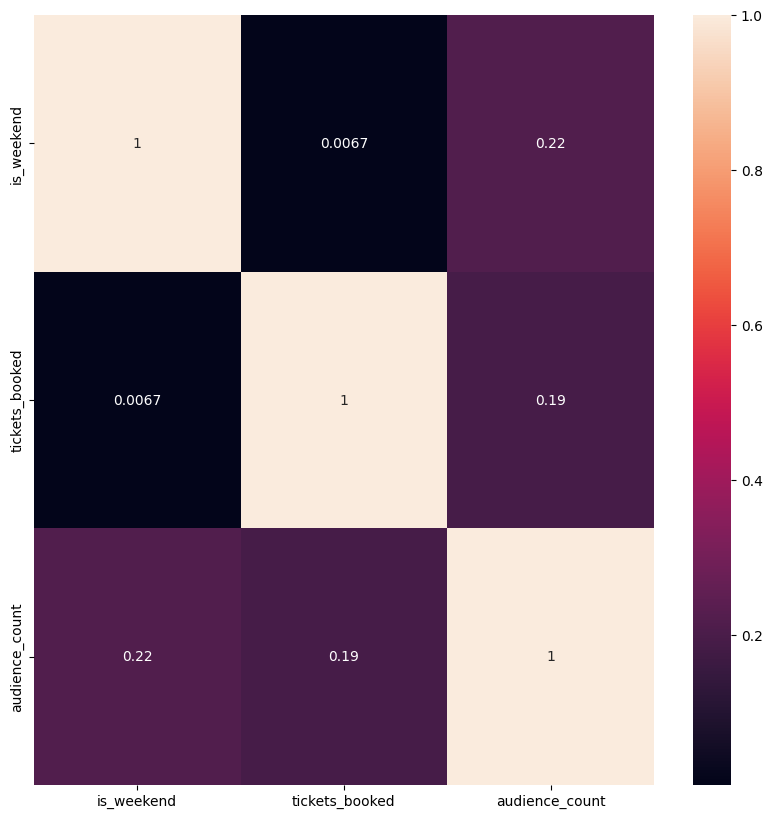

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))
sns.heatmap(combined1.select_dtypes(include='number').corr(),annot=True)

# 3. Data Integration – Method 02

I combined online (BookNow) and offline (CinePOS) bookings to get total show-level bookings and merged them with audience data.

---

### 1. Online Bookings (BookNow)

* Converted `show_datetime` and extracted `show_date`.
* Summed tickets per show using `groupby(book_theater_id, show_date)`.
* Dropped unused datetime columns.

---

### 2. Offline Bookings (CinePOS)

* Converted `show_datetime` and extracted `show_date`.
* Summed tickets using `groupby(cine_theater_id, show_date)`.
* Mapped CinePOS theater IDs to BookNow IDs.
* Removed unmapped rows and standardized the ID column.

---

### 3. Combine Both Sources

* Concatenated both datasets.
* Removed duplicates.

---

### 4. Merge Audience Count

* Converted visit `show_date`.
* Merged using `book_theater_id` and `show_date`.
* Kept only essential columns.

---

### 5. Final Output

* Columns: `book_theater_id`, `show_date`, `tickets_booked`, `audience_count`.
* Each row represents one show with total bookings and actual audience.

---

### ✅ Summary

I created a clean, unified show-level dataset ready for analysis.


In [ ]:
# Method 02

# book id + show date + total booking
booknow_booking_cpy = booknow_booking.copy()
booknow_booking_cpy['show_datetime'] = pd.to_datetime(booknow_booking_cpy['show_datetime'])
booknow_booking_cpy['show_date'] = booknow_booking_cpy['show_datetime'].dt.date

booknow_booking_cpy['tickets_booked'] = (
    booknow_booking_cpy
    .groupby(['book_theater_id', 'show_date'])['tickets_booked']
    .transform('sum'))
booknow_booking_cpy.drop(columns=['show_datetime','booking_datetime'],axis=1,inplace=True)


# converted cine id + show date + total booking
cinepos_booking_cpy = cinepos_booking.copy()
cinepos_booking_cpy['show_datetime'] = pd.to_datetime(cinepos_booking_cpy['show_datetime'])
cinepos_booking_cpy['show_date'] = cinepos_booking_cpy['show_datetime'].dt.date

cinepos_booking_cpy['tickets_booked'] = (
    cinepos_booking_cpy
    .groupby(['cine_theater_id', 'show_date'])['tickets_sold']
    .transform('sum'))
cinepos_booking_cpy.drop(columns=['show_datetime','booking_datetime','tickets_sold'],axis=1,inplace=True)

# ID conversion
id_map = dict(zip(id_relation['cine_theater_id'], id_relation['book_theater_id']))
cinepos_booking_cpy['cine_theater_id'] = cinepos_booking_cpy['cine_theater_id'].map(id_map)
cinepos_booking_cpy.dropna(inplace= True)
cinepos_booking_cpy.rename(columns={'cine_theater_id': 'book_theater_id'}, inplace=True)

# combined2 both and remove duplicates
combined2 = pd.concat([booknow_booking_cpy,cinepos_booking_cpy],axis =0,ignore_index= True)
combined2.drop_duplicates(inplace=True, ignore_index=True)

# now merge with vistis
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date']).dt.date
combined2 = pd.merge(
    combined2,
    booknow_visits,
    how='inner',
    on=['book_theater_id', 'show_date']
)
combined2 = combined2[['book_theater_id','show_date', 'tickets_booked','audience_count']]

del id_map,booknow_booking_cpy,cinepos_booking_cpy
combined2.head()

,book_theater_id,show_date,tickets_booked,audience_count
0,book_00244,2023-01-01,3,6
1,book_00740,2023-01-01,9,42
2,book_00151,2023-01-01,5,16
3,book_00151,2023-01-02,34,188
4,book_00106,2023-01-02,4,78


## 3.1 EDA on Method 02

In [ ]:
combined2.shape

(31073, 4)

In [ ]:
combined2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31073 entries, 0 to 31072
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  31073 non-null  object
 1   show_date        31073 non-null  object
 2   tickets_booked   31073 non-null  int64 
 3   audience_count   31073 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 971.2+ KB


In [ ]:
combined2.isnull().sum()

book_theater_id    0
show_date          0
tickets_booked     0
audience_count     0
dtype: int64

In [ ]:
print('Number of duplicates before removing them: ',combined2.duplicated().sum())
combined2.drop_duplicates(inplace=True,ignore_index=True)
print('Number of duplicates after removing them: ',combined2.duplicated().sum())

Number of duplicates before removing them:  0
Number of duplicates after removing them:  0


In [ ]:
print("Unique theater IDs", combined2['book_theater_id'].nunique())

Unique theater IDs 320


In [ ]:
combined2['show_date'] = pd.to_datetime(combined2['show_date'])
print("min show date:",combined2['show_date'].min())
print("max show date:",combined2['show_date'].max())

min show date: 2023-01-01 00:00:00
max show date: 2024-02-28 00:00:00


<Axes: >

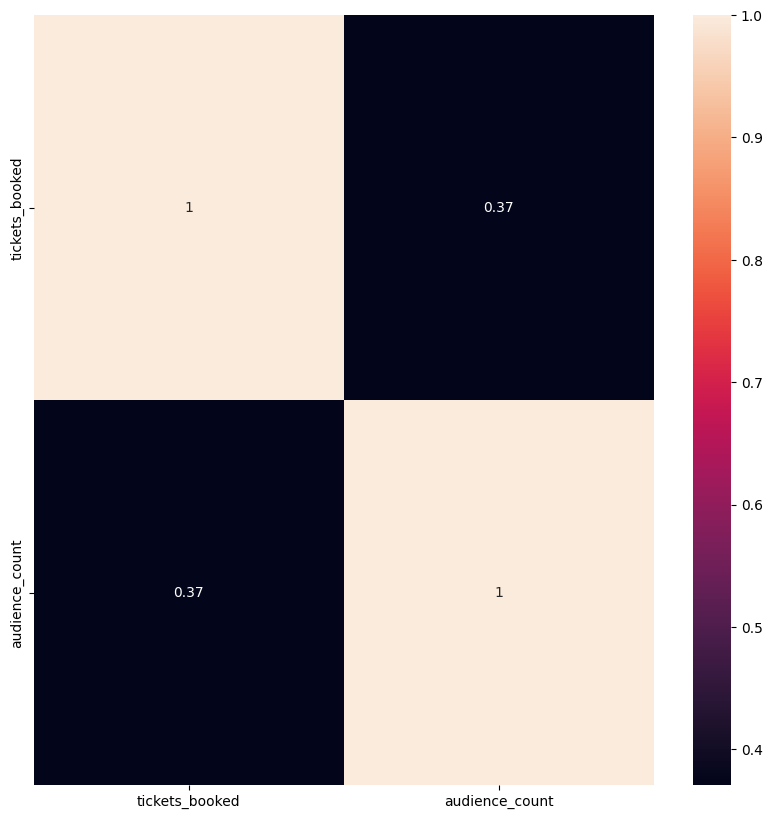

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))
sns.heatmap(combined2.select_dtypes(include='number').corr(),annot=True)

# 4. Data Integration - Method 03

I generated a complete daily timeline for every theater and merged it with the original visits data to ensure no dates were missing.

---

### 1. Prepare Date Range

* Converted `show_date` to datetime.
* Identified the minimum and maximum dates.
* Created a full date range between them.

---

### 2. Create Full Theater–Date Grid

* Took all unique theater IDs.
* Built a complete grid of **every theater × every date**.

---

### 3. Merge With Original Data

* Merged the full grid with `booknow_visits`.
* Missing `audience_count` values represent days with no recorded visits
  (optionally filled with 0).

---

### Final Output

A dataset where **every theater has an entry for every date** in the range, ensuring full continuity for time-series analysis.

In [ ]:
# making dates continous
import warnings
warnings.filterwarnings("ignore")

booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"])

# Set the date range you want
start_date = booknow_visits['show_date'].min()
end_date   = booknow_visits['show_date'].max()

full_dates = pd.date_range(
    start=start_date,
    end=end_date)

# Create a complete grid: every theater × every date
theaters = booknow_visits["book_theater_id"].unique()
full_grid = pd.MultiIndex.from_product(
    [theaters, full_dates],
    names=["book_theater_id", "show_date"]
).to_frame(index=False)

# Merge with original data
final_df = pd.merge(
    full_grid,
    booknow_visits,
    on=["book_theater_id", "show_date"],
    how="left"
)

# Fill missing audience_count with 0 (or keep it as NaN if you prefer)
# final_df["audience_count"] = final_df["audience_count"].fillna(0)

final_df.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-01,NaN
1,book_00001,2023-01-02,NaN
2,book_00001,2023-01-03,NaN
3,book_00001,2023-01-04,NaN
4,book_00001,2023-01-05,NaN


In [ ]:
print('Missing Values:')
print(final_df.isnull().sum())
print('\n')

print('Missing Values %:')
print(final_df.isnull().sum() / len(final_df) *100)

Missing Values:
book_theater_id         0
show_date               0
audience_count     136353
dtype: int64


Missing Values %:
book_theater_id     0.000000
show_date           0.000000
audience_count     38.913638
dtype: float64


## 4.1 Audience Count Gap Filling

I filled missing `audience_count` values using different rules based on the size of each gap.

---

### 1. Process Each Theater Separately

* Sorted data by theater and date.
* Identified continuous missing segments (`gaps`) in `audience_count`.

---

### 2. Apply Gap-Filling Rules

* **Small gaps (≤ 7 days):** Forward–backward fill.
* **Medium gaps (8–30 days):** Filled using the **average by weekday**.
* **Large gaps (> 30 days):** Filled using the **overall median** of that theater.

---

### 3. Final Output

All missing values are filled using consistent rules, ensuring a smooth and reliable time series for each theater.

In [ ]:
# # Audience Count Gap Filling
def fill_gaps(df):
    df = df.sort_values(["book_theater_id", "show_date"]).copy()

    # Final filled output
    result = []

    # Process each theater separately
    for tid, temp in df.groupby("book_theater_id"):
        temp = temp.reset_index(drop=True)

        i = 0
        while i < len(temp):
            # If value is not missing → move on
            if not pd.isna(temp.loc[i, "audience_count"]):
                i += 1
                continue

            # Start of gap
            start = i
            while i < len(temp) and pd.isna(temp.loc[i, "audience_count"]):
                i += 1
            end = i - 1

            gap_len = end - start + 1

            # -------------------------
            # APPLY RULE BASED ON GAP SIZE
            # -------------------------

            # Small gap (<=7)
            if gap_len <= 7:
                temp.loc[start:end, "audience_count"] = temp["audience_count"].ffill().bfill()

            # Medium gap (8–30)
            elif 8 <= gap_len <= 30:
                temp.loc[start:end, "audience_count"] = (
                    temp.groupby(temp["show_date"].dt.weekday)["audience_count"]
                    .transform(lambda x: x.fillna(x.mean()))
                )

            # Large gap (>30)
            else:
                med = temp["audience_count"].median()
                temp.loc[start:end, "audience_count"] = med

        result.append(temp)

    return pd.concat(result)

final_df = fill_gaps(final_df)
final_df.isnull().sum()

book_theater_id    0
show_date          0
audience_count     0
dtype: int64

## 4.2 EDA on Method 03

In [ ]:
# Shape
# final_df.shape

(350399, 3)

In [ ]:
# Basic Info
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350399 entries, 0 to 423
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  350399 non-null  object        
 1   show_date        350399 non-null  datetime64[ns]
 2   audience_count   350399 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 10.7+ MB


In [ ]:
# Summary
final_df.drop('show_date',axis=1).describe()

,audience_count
count,350399.000000
mean,40.513995
std,30.345396
min,2.000000
25%,18.000000
50%,34.000000
75%,56.000000
max,1350.000000


In [ ]:
# Missing values
final_df.isnull().sum()

book_theater_id    0
show_date          0
audience_count     0
dtype: int64

In [ ]:
# Duplicates
print('Number of duplicates before removing them: ',final_df.duplicated().sum())
final_df.drop_duplicates(inplace=True,ignore_index=True)
print('Number of duplicates after removing them: ',final_df.duplicated().sum())

Number of duplicates before removing them:  10
Number of duplicates after removing them:  0


In [ ]:
# Unique IDs
print("Unique theater IDs", final_df['book_theater_id'].nunique())

Unique theater IDs 826


In [ ]:
# Date Range
final_df['show_date'] = pd.to_datetime(final_df['show_date'])
print("min show date:",final_df['show_date'].min())
print("max show date:",final_df['show_date'].max())

min show date: 2023-01-01 00:00:00
max show date: 2024-02-28 00:00:00


In [ ]:
import matplotlib.pyplot as plt

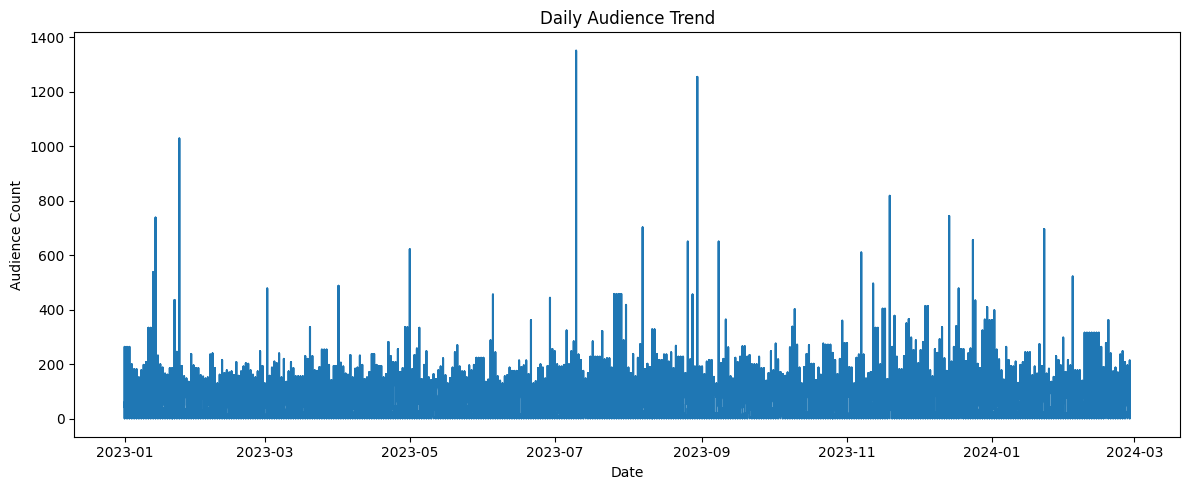

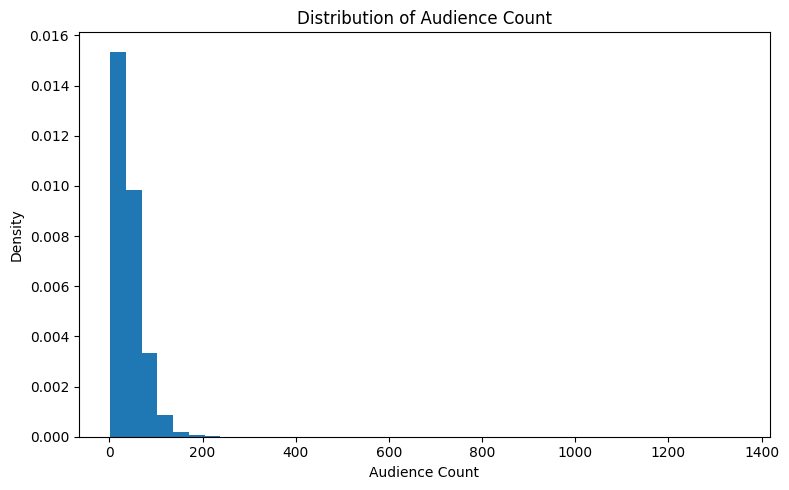

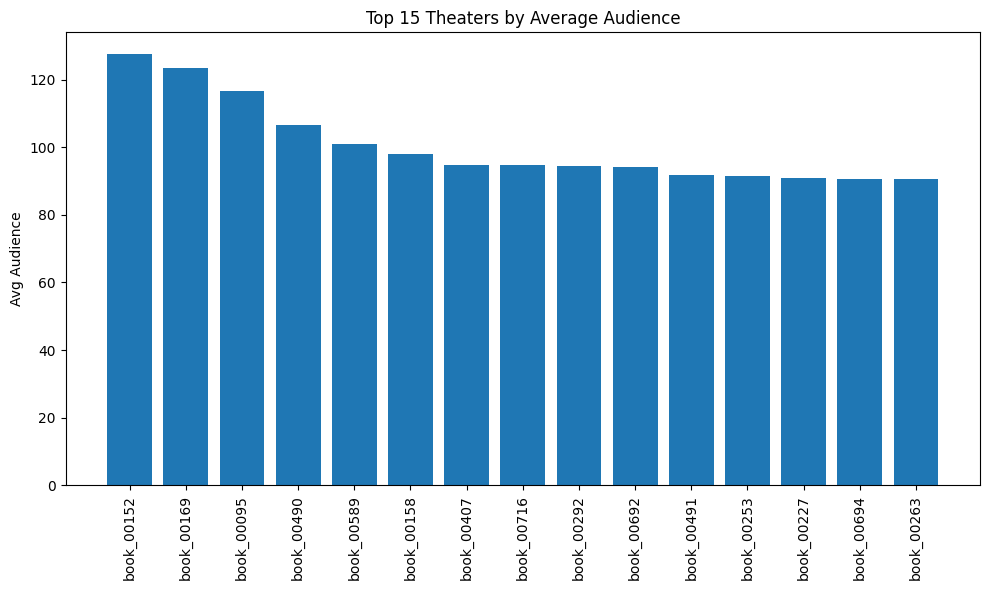

In [ ]:
# ===============================
# Daily audience trend (time-series line chart)
# ===============================
df = final_df

df_sorted = df.sort_values("show_date")
plt.figure(figsize=(12,5))
plt.plot(df_sorted['show_date'], df_sorted['audience_count'])
plt.xlabel("Date")
plt.ylabel("Audience Count")
plt.title("Daily Audience Trend")
plt.tight_layout()
plt.show()


# ===============================
# Audience distribution (histogram + KDE)
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df['audience_count'], bins=40, density=True)
plt.xlabel("Audience Count")
plt.ylabel("Density")
plt.title("Distribution of Audience Count")
plt.tight_layout()
plt.show()


# ===============================
# Top theaters by average audience (bar plot)
# ===============================
top_theaters = (df.groupby("book_theater_id")['audience_count']
                  .mean()
                  .sort_values(ascending=False)
                  .head(15))

plt.figure(figsize=(10,6))
plt.bar(top_theaters.index, top_theaters.values)
plt.xticks(rotation=90)
plt.ylabel("Avg Audience")
plt.title("Top 15 Theaters by Average Audience")
plt.tight_layout()
plt.show()

## 4.3 Metadata Generation

* It loops through each theater and creates metadata by computing:
---
### **1. Decomposition**

* Tries **multiplicative**, then **additive**.
* Extracts **trend**, **seasonal**, **residual**.
* If series is too short → marks as *Neither*.
---
### **2. Stationarity**

* Runs **ADF**, **KPSS**, and a **KS test**.
* Combines results to label:

  * **Strict Stationary**
  * **Weak Stationary**
  * **Non-Stationary**
  * Or “Not enough data”.
---
### **3. Summary Stats**

* Calculates **max**, **min**, and **average** audience count.
---
Finally, it stores everything in a clean DataFrame called `meta_data`.

In [ ]:
# meta data

import pandas as pd
import warnings
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import ks_2samp

df = final_df.copy()
df['show_date'] = pd.to_datetime(df['show_date'])
df = df.sort_values(['book_theater_id', 'show_date'])

period = 7
min_decomp_len = period * 2       # for decomposition
min_stat_len = 14                 # for stationarity tests

results = []

for _id, group in df.groupby('book_theater_id'):

    # prepare series
    series = group.groupby('show_date')['audience_count'].sum()

    # theater-level statistics (correct)
    max_val = group['audience_count'].max()
    min_val = group['audience_count'].min()
    avg_val = group['audience_count'].mean()

    # ---------------------
    # Classical Decomposition
    # ---------------------
    if len(series) < min_decomp_len:
        model_type = 'Neither'
        trend = seasonal = resid = None
    else:
        try:
            result = seasonal_decompose(series, model='multiplicative', period=period)
            model_type = 'Multiplicative'
        except:
            try:
                result = seasonal_decompose(series, model='additive', period=period)
                model_type = 'Additive'
            except:
                result = None
                model_type = 'Neither'

        if result is not None:
            trend = result.trend
            seasonal = result.seasonal
            resid = result.resid
        else:
            trend = seasonal = resid = None

    # ---------------------
    # Stationarity Tests
    # ---------------------
    series_stat = series.dropna()

    if len(series_stat) < min_stat_len:
        final_status = 'Not enough data'
    else:
        # ADF (Weak stationarity test)
        try:
            # Purpose: Check for unit root → weak stationarity.
            # Hypothesis: H₀: Non-stationary (unit root exists), H₁: Stationary.
            # Evaluation: p-value < 0.05 → reject H₀ → series is stationary.
            # autolag='AIC' : automatically chooses the number of lag terms
            adf_pvalue = adfuller(series_stat, autolag='AIC')[1]
            adf_stationary = adf_pvalue < 0.05
        except:
            adf_stationary = False

        # KPSS (Weak stationariyt test)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                # Purpose: Check trend or level stationarity.
                # Hypothesis: H₀: Stationary, H₁: Non-stationary.
                # Evaluation: p-value > 0.05 → fail to reject H₀ → series is stationary.
                # regression='c' → tests constant mean stationarity (no trend).
                # nlags='auto' → automatically chooses lag based on series length.
                kpss_pvalue = kpss(series_stat, regression='c', nlags='auto')[1]
                kpss_stationary = kpss_pvalue > 0.05
            except:
                kpss_stationary = False

        weak_stationary = adf_stationary and kpss_stationary

        # KS test (strict stationarity test)
        # Purpose: Compare distributions → strict stationarity.
        # Hypothesis: H₀: Both samples come from the same distribution, H₁: Different distributions.
        # Evaluation: p-value > 0.05 → fail to reject H₀ → distribution unchanged → strictly stationary.
        mid = len(series_stat) // 2
        first_half, second_half = series_stat[:mid], series_stat[mid:]
        ks_stat, ks_pvalue = ks_2samp(first_half, second_half)
        strict_stationary = ks_pvalue > 0.05

        if not weak_stationary:
            final_status = 'Non-Stationary'
        elif strict_stationary:
            final_status = 'Strict Stationary'
        else:
            final_status = 'Weak Stationary'

    # ---------------------
    # Append final row
    # ---------------------
    results.append({
        'book_theater_id': _id,
        'model': model_type,
        'trend': trend,
        'seasonal': seasonal,
        'resid': resid,
        'stationarity': final_status,
        'max': max_val,
        'min': min_val,
        'avg': avg_val
    })

# Final DataFrame
meta_data = pd.DataFrame(results)

meta_data.head()

,book_theater_id,model,trend,seasonal,resid,stationarity,max,min,avg
0,book_00001,Multiplicative,show_date 2023-01-01 NaN 2023-01-02 ...,show_date 2023-01-01 1.261278 2023-01-02 ...,show_date 2023-01-01 NaN 2023-01-02 ...,Non-Stationary,122.0,2.0,48.801620
1,book_00002,Multiplicative,show_date 2023-01-01 NaN 2023-01-02 ...,show_date 2023-01-01 1.193667 2023-01-02 ...,show_date 2023-01-01 NaN 2023-01-02 ...,Non-Stationary,100.0,2.0,12.259434
2,book_00003,Multiplicative,show_date 2023-01-01 NaN 2023-01-02 ...,show_date 2023-01-01 1.177011 2023-01-02 ...,show_date 2023-01-01 NaN 2023-01-02 ...,Non-Stationary,132.0,4.0,55.780660
3,book_00004,Multiplicative,show_date 2023-01-01 NaN 2023-01-02 ...,show_date 2023-01-01 1.179950 2023-01-02 ...,show_date 2023-01-01 NaN 2023-01-02 ...,Non-Stationary,86.0,2.0,20.416471
4,book_00005,Multiplicative,show_date 2023-01-01 NaN 2023-01-02 ...,show_date 2023-01-01 1.089518 2023-01-02 ...,show_date 2023-01-01 NaN 2023-01-02 ...,Weak Stationary,134.0,2.0,51.556604


In [ ]:
meta_data['model'].value_counts()

model
Multiplicative    826
Name: count, dtype: int64

In [ ]:
meta_data['stationarity'].value_counts()

stationarity
Non-Stationary       403
Weak Stationary      286
Strict Stationary    137
Name: count, dtype: int64

# 5. Model Training

## 5.1 LGBMRegressor

This workflow builds a **LightGBM time-series model** with **feature engineering**, **hyperparameter tuning**, **cross-validated evaluation**, and **meta-based prediction adjustment**.

---
### **1. Data Preparation**

* Copy input DataFrames to avoid modifying originals.
* Sort by theater + date and extract date features: year, month, day, day-of-week.

### **2. Train/Test Feature Setup**

* Training features come from `final_df`.
* Test features are parsed from `sample_submission`’s `ID` column (`book_theater_id_date` format).

### **3. Preprocessing**

* Numeric columns → standardized.
* Categorical IDs → one-hot encoded (dense output to avoid sparse-shape issues).
* Combined using a `ColumnTransformer`.

### **4. Model + Hyperparameter Tuning**

* Base model: LightGBM.
* For each TimeSeriesSplit fold:

  * A separate pipeline is created.
  * **RandomizedSearchCV** (with its own inner TSSplit) tunes parameters.
  * Best model predicts the validation fold.
  * R² metrics are collected.

### **5. Final Training**

* A fresh pipeline is trained on **all data** using the base model.

### **6. Test Prediction**

* Predict on processed test set.
* Negative outputs are clipped to zero.

### **7. Meta-Based Adjustment**

For each theater:

* Clip prediction within meta min/max.
* Blend with meta average:
  `final = 0.7 * clipped + 0.3 * avg`

### **8. Output**

* Final adjusted predictions are placed in `sample_submission["audience_count"]`.
* Ready for submission.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV

# ----------------------------
# Assume these DataFrames are provided:
# final_df, meta_data, sample_submission
# ----------------------------

# 1. Copy and dtypes
final_df_cpy = final_df.copy()
meta_df = meta_data.copy()
sample_sub = sample_submission.copy()

final_df_cpy["show_date"] = pd.to_datetime(final_df_cpy["show_date"])

# 2. Feature engineering (date features)
final_df_cpy = final_df_cpy.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)
final_df_cpy["year"] = final_df_cpy["show_date"].dt.year
final_df_cpy["month"] = final_df_cpy["show_date"].dt.month
final_df_cpy["day"] = final_df_cpy["show_date"].dt.day
final_df_cpy["dayofweek"] = final_df_cpy["show_date"].dt.dayofweek

target_col = "audience_count"
feature_cols = ["book_theater_id", "year", "month", "day", "dayofweek"]

X = final_df_cpy[feature_cols].copy()
y = final_df_cpy[target_col].copy()

numeric_features = ["year", "month", "day", "dayofweek"]
categorical_features = ["book_theater_id"]

# 3. Prepare test from sample_submission
# ID : book_00001_2024-03-01
sample_sub[['book_theater_id', 'show_date']] = sample_sub['ID'].str.rsplit('_', n=1, expand=True)
sample_sub["show_date"] = pd.to_datetime(sample_sub["show_date"])

test_df = sample_sub.copy()
test_df["year"] = test_df["show_date"].dt.year
test_df["month"] = test_df["show_date"].dt.month
test_df["day"] = test_df["show_date"].dt.day
test_df["dayofweek"] = test_df["show_date"].dt.dayofweek

X_test = test_df[feature_cols].copy().reset_index(drop=True)

# 4. Preprocessor
numeric_transformer = StandardScaler()
# Use dense output
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# model template (we will clone per fold)
model_template = LGBMRegressor(
    n_estimators=400,       # Number of boosting rounds
    learning_rate=0.05,     # Step size shrinkage.
    subsample=0.8,          # Fraction of data to use for each tree.
    colsample_bytree=0.8,   # Fraction of features to use for each tree.
    random_state=42
)

def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    return {"R2 Score": r2}

# 5. TimeSeriesSplit evaluation — creating a fresh pipeline/model per fold
tscv = TimeSeriesSplit(n_splits=3)
rmse_scores = []
metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X, y)):
    X_train, X_val = X.iloc[train_idx].reset_index(drop=True), X.iloc[val_idx].reset_index(drop=True)
    y_train, y_val = y.iloc[train_idx].reset_index(drop=True), y.iloc[val_idx].reset_index(drop=True)

    # creating a fresh pipeline for this fold so the preprocessor is fit on X_train only
    pipeline_fold = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", clone(model_template))
        ]
    )

    # hyperparameter distribution
    param_dist = {
        "model__num_leaves": [31, 50, 70],          # Maximum number of leaves per tree
        "model__max_depth": [-1, 5, 10, 15],        # Maximum depth of each tree.
        "model__learning_rate": [0.01, 0.03, 0.05], # Shrinkage rate for updates.
        "model__n_estimators": [300, 400, 600],     # Number of boosting rounds (trees).
        "model__subsample": [0.7, 0.8, 0.9],        # Fraction of data used for each tree.
        "model__colsample_bytree": [0.7, 0.8, 0.9], # Fraction of features used per tree.
    }

    # Use an inner time-series split for the RandomizedSearchCV CV
    inner_cv = TimeSeriesSplit(n_splits=3)

    search = RandomizedSearchCV(
        estimator=pipeline_fold,
        param_distributions=param_dist,
        n_iter=10,
        scoring="r2",
        cv=inner_cv,
        verbose=1,
        n_jobs=-1,
        random_state=42,
        refit=True  # keep default: best_estimator_ will be refit on X_train
    )

    # Fit the search **only on the training fold** (important)
    search.fit(X_train, y_train)

    print(f"Fold {fold} - Best Params:", search.best_params_)

    # best_estimator_ is already refit on X_train by RandomizedSearchCV (so encoder/categories match)
    best_pipeline = search.best_estimator_

    # directly predict on validation set
    y_pred = best_pipeline.predict(X_val)

    metrics = regression_metrics(y_val, y_pred)
    metrics["Fold"] = fold
    metrics_list.append(metrics)

# Convert collected metrics to DataFrame (unchanged)
metrics_df = pd.DataFrame(metrics_list)

# 6. Train final model on ALL data (fresh pipeline)
final_model = clone(model_template)
final_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", final_model)])
final_pipeline.fit(X.reset_index(drop=True), y.reset_index(drop=True))

# 7. Predict on test
raw_pred = final_pipeline.predict(X_test)
raw_pred = np.clip(raw_pred, 0, None)  # no negative audience

# 8. Meta adjustments (defensive)
meta_map = meta_df.set_index("book_theater_id")[["min", "max", "avg"]]

adjusted_pred = []
for i, row in test_df.reset_index(drop=True).iterrows():
    pred = raw_pred[i]
    book_id = row["book_theater_id"]
    if book_id in meta_map.index:
        meta_row = meta_map.loc[book_id]
        meta_min = meta_row["min"]
        meta_max = meta_row["max"]
        meta_avg = meta_row["avg"]

        # Clip then blend
        pred = np.clip(pred, meta_min, meta_max)
        pred = 0.7 * pred + 0.3 * meta_avg
    else:
        pred = max(pred, 0.0)

    adjusted_pred.append(pred)

adjusted_pred = np.clip(np.array(adjusted_pred), 0, None)

# 9. Save submission
sample_sub["audience_count"] = adjusted_pred

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 108
[LightGBM] [Info] Number of data points in the train set: 21902, number of used features: 5
[LightGBM] [Info] Start training from score 42.765464
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 160
[LightGBM] [Info] Number of data points in the train set: 43802, number of used features: 5
[LightGBM] [Info] Start training from score 46.729083
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, yo

In [ ]:
metrics_df

,R2 Score,Fold
0,-0.088201,0
1,0.000230,1
2,-0.044105,2


In [ ]:
sample_sub.drop(columns=['book_theater_id','show_date'],axis=1, inplace= True)
sample_sub.head()

,ID,audience_count
0,book_00001_2024-03-01,40.993443
1,book_00001_2024-03-02,52.069704
2,book_00001_2024-03-03,56.514276
3,book_00001_2024-03-04,44.375896
4,book_00001_2024-03-06,35.929423


## 5.2 XGBRegressor

This workflow trains an **XGBoost regression model** for time-series forecasting using:

* Feature engineering
* Cross-validated hyperparameter tuning
* A preprocessing pipeline
* Meta-based post-processing adjustments

---
### **1. Data Preparation**

* Copy input DataFrames to preserve originals.
* Convert date fields and make IDs strings.
* Sort data by theater and date.
* Extract date-based features: year, month, day, weekday.

### **2. Train/Test Feature Construction**

* Training features come from `final_df`.
* Test features are extracted from `sample_submission` using its encoded ID (`theater_date`).

### **3. Preprocessing Pipeline**

* Numeric features → scaled using `StandardScaler`.
* Categorical theater IDs → one-hot encoded (dense output).
* Combined using `ColumnTransformer`.

### **4. Model + Hyperparameter Tuning**

* Base model: **XGBoost Regressor**.
* For each TimeSeriesSplit fold:

  * Build a fold-specific pipeline.
  * Use **RandomizedSearchCV** with an inner TSSplit to tune parameters such as:
    depth, learning rate, subsample, colsample, gamma, regularization.
  * Fit only on the training part of each split.
  * Predict on the validation window and store R² metrics.

### **5. Final Training**

* A fresh pipeline is fitted on **all available data** for the final model.

### **6. Test Prediction**

* Predict using the final pipeline.
* Negative values are clipped to zero.

### **7. Meta-Based Adjustments**

For each theater:

* Clip prediction within per-theater min–max bounds.
* Blend with the per-theater average:
  `adjusted = 0.7 * clipped + 0.3 * avg`.

### **8. Submission Output**

* The final adjusted audience values are inserted into the submission DataFrame.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import r2_score
from xgboost import XGBRegressor


# 1. Copy and dtypes
final_df_cpy = final_df.copy()
meta_df = meta_data.copy()
sample_sub = sample_submission.copy()

final_df_cpy["show_date"] = pd.to_datetime(final_df_cpy["show_date"])

# 2. Feature engineering (date features)
final_df_cpy = final_df_cpy.sort_values(["book_theater_id", "show_date"]).reset_index(drop=True)
final_df_cpy["year"] = final_df_cpy["show_date"].dt.year
final_df_cpy["month"] = final_df_cpy["show_date"].dt.month
final_df_cpy["day"] = final_df_cpy["show_date"].dt.day
final_df_cpy["dayofweek"] = final_df_cpy["show_date"].dt.dayofweek

target_col = "audience_count"
feature_cols = ["book_theater_id", "year", "month", "day", "dayofweek"]

X = final_df_cpy[feature_cols].copy()
y = final_df_cpy[target_col].copy()

numeric_features = ["year", "month", "day", "dayofweek"]
categorical_features = ["book_theater_id"]

# 3. Prepare test from sample_submission
sample_sub[['book_theater_id', 'show_date']] = sample_sub['ID'].str.rsplit('_', n=1, expand=True)
sample_sub["show_date"] = pd.to_datetime(sample_sub["show_date"])

test_df = sample_sub.copy()
test_df["year"] = test_df["show_date"].dt.year
test_df["month"] = test_df["show_date"].dt.month
test_df["day"] = test_df["show_date"].dt.day
test_df["dayofweek"] = test_df["show_date"].dt.dayofweek

X_test = test_df[feature_cols].copy().reset_index(drop=True)

# 4. Preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# model template: XGBoost regressor
model_template = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    return {
        "R2 Score": r2,
    }

# 5. TimeSeriesSplit evaluation — create a fresh pipeline/model per fold
tscv = TimeSeriesSplit(n_splits=3)
metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X, y)):
    X_train, X_val = X.iloc[train_idx].reset_index(drop=True), X.iloc[val_idx].reset_index(drop=True)
    y_train, y_val = y.iloc[train_idx].reset_index(drop=True), y.iloc[val_idx].reset_index(drop=True)

    pipeline_fold = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", clone(model_template))
        ]
    )

    # hyperparameter distribution for XGBoost (keys use pipeline prefix "model__")
    param_dist = {
        "model__n_estimators": [300, 400, 600],
        "model__learning_rate": [0.01, 0.03, 0.05],
        "model__max_depth": [3, 5, 7, 10],
        "model__subsample": [0.6, 0.7, 0.8, 0.9],
        "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9],
        "model__gamma": [0, 0.1, 0.5],            # min loss reduction
        "model__reg_alpha": [0, 0.1, 1.0],        # L1 reg
        "model__reg_lambda": [1.0, 2.0, 5.0],     # L2 reg
    }

    inner_cv = TimeSeriesSplit(n_splits=3)

    search = RandomizedSearchCV(
        estimator=pipeline_fold,
        param_distributions=param_dist,
        n_iter=12,
        scoring="r2",
        cv=inner_cv,
        verbose=1,
        n_jobs=-1,
        random_state=42,
        refit=True
    )

    # Fit the search only on the training fold
    search.fit(X_train, y_train)

    print(f"Fold {fold} - Best Params:", search.best_params_)

    best_pipeline = search.best_estimator_

    y_pred = best_pipeline.predict(X_val)

    metrics = regression_metrics(y_val, y_pred)
    metrics["Fold"] = fold
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)

# 6. Train final model on ALL data (fresh pipeline)
final_model = clone(model_template)
final_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("model", final_model)])
final_pipeline.fit(X.reset_index(drop=True), y.reset_index(drop=True))

# 7. Predict on test
raw_pred = final_pipeline.predict(X_test)
raw_pred = np.clip(raw_pred, 0, None)  # no negative audience

# 8. Meta adjustments (defensive)
meta_map = meta_df.set_index("book_theater_id")[["min", "max", "avg"]]

adjusted_pred = []
for i, row in test_df.reset_index(drop=True).iterrows():
    book_id = str(row["book_theater_id"])
    pred = raw_pred[i]

    if book_id in meta_map.index:
        meta_row = meta_map.loc[book_id]
        meta_min = meta_row["min"]
        meta_max = meta_row["max"]
        meta_avg = meta_row["avg"]

        pred = np.clip(pred, meta_min, meta_max)
        pred = 0.7 * pred + 0.3 * meta_avg
    else:
        pred = max(pred, 0.0)

    adjusted_pred.append(pred)

adjusted_pred = np.clip(np.array(adjusted_pred), 0, None)

# 9. Save submission
sample_sub["audience_count"] = adjusted_pred

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fold 0 - Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 5.0, 'model__reg_alpha': 1.0, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.7}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fold 1 - Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 5.0, 'model__reg_alpha': 1.0, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.6}
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fold 2 - Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 5.0, 'model__reg_alpha': 1.0, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.6}


In [ ]:
metrics_df

,R2 Score,Fold
0,-0.038752,0
1,-0.004262,1
2,0.002701,2


In [ ]:
sample_sub.drop(columns=['book_theater_id','show_date'],axis=1, inplace= True)
sample_sub.head()

,ID,audience_count
0,book_00001_2024-03-01,29.938189
1,book_00001_2024-03-02,37.869899
2,book_00001_2024-03-03,44.385629
3,book_00001_2024-03-04,39.678461
4,book_00001_2024-03-06,30.231131


## 5.3 ARIMA

The script builds **per-theater ARIMA models** and evaluates them with **time-series cross-validation**.

### **1. Setup**

* Load ARIMA (uses `auto_arima` if available).
* Maintain global true/predicted lists for final R².

### **2. Per-Theater Processing (`fit_and_forecast`)**

* Select that theater’s history, sort by date, and extract meta info (model type, stationarity, trend, seasonal, resid).
* Build the target series:

  * Multiplicative → log transform.
  * Otherwise → raw values.
* Extract min/max/avg for later constraints.

### **3. Time-Series Cross-Validation**

* Use `TimeSeriesSplit` to train ARIMA on rolling windows.
* Predict each validation block.
* Reverse-transform if needed.
* Store predictions in global lists for R².

### **4. Final Model & Forecast**

* Refit ARIMA on all available data.
* Forecast each required future date in `sample_submission`.
* Reverse-transform (log), or adjust for additive trend/seasonal when needed.

### **5. Post-Processing**

* Blend with historical average: `0.7 * pred + 0.3 * avg`.
* Clip predictions within per-theater min–max.
* Fill submission rows.

### **6. Final Output**

* Loop over all theaters, run forecasting.
* Compute one global R² using all CV predictions.
* Insert results into submission file.

In [ ]:
print("R² Score:", GLOBAL_R2)

R² Score: 0.418345290962557


In [ ]:
sample_submission.drop(columns=['book_theater_id','show_date'],axis=1, inplace= True)
sample_submission.head()

,ID,audience_count
0,book_00001_2024-03-01,42.267954
1,book_00001_2024-03-02,42.807017
2,book_00001_2024-03-03,42.932707
3,book_00001_2024-03-04,42.962014
4,book_00001_2024-03-06,42.970440


In [ ]:
sample_submission.to_csv("submission.csv", index=False)

In [ ]:
# arima with meta data with imputed continuous dates
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline


GLOBAL_TRUE = []
GLOBAL_PRED = []

try:
    from pmdarima import auto_arima
    USE_AUTO_ARIMA = True
except ImportError:
    from statsmodels.tsa.arima.model import ARIMA
    USE_AUTO_ARIMA = False


def fit_and_forecast(tid, df, meta_df, sample_submission):
    tdf = df[df["book_theater_id"] == tid].copy()
    tdf = tdf.sort_values("show_date").set_index("show_date")

    if len(tdf) < 5:
        mean_count = tdf["audience_count"].mean()
        sample_submission.loc[sample_submission["book_theater_id"] == tid, "audience_count"] = mean_count
        return sample_submission

    # Fetch meta info from meta_df
    if tid in meta_df.index:
        meta = meta_df.loc[tid]
    else:
        meta = {}

    model_type = meta.get("model", "Neither")
    stationarity = meta.get("stationarity", "Non-Stationary")
    trend = meta.get("trend", pd.Series([0]*len(tdf), index=tdf.index))
    seasonal = meta.get("seasonal", pd.Series([0]*len(tdf), index=tdf.index))
    resid = meta.get("resid", pd.Series([0]*len(tdf), index=tdf.index))
    min_val = meta.get("min", tdf["audience_count"].min())
    max_val = meta.get("max", tdf["audience_count"].max())
    avg_val = meta.get("avg", tdf["audience_count"].mean())

    y = tdf["audience_count"].astype(float)

    if model_type == "Multiplicative":
        y_clean = np.where(y <= 0, np.nan, y)
        y_log = np.log(y_clean)
        y_model = pd.Series(y_log).fillna(0)
    else:
        y_model = y.fillna(0)

    # ----------------------------------------------------
    # TIME SERIES SPLIT + R² CONTRIBUTION
    # ----------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=3)

    for train_idx, test_idx in tscv.split(y_model):
        y_train = y_model.iloc[train_idx]
        y_test = y_model.iloc[test_idx]

        # Fit ARIMA on training split
        if USE_AUTO_ARIMA:
            d_hint = 0 if "Strict" in stationarity else 1
            model = auto_arima(
                y_model,
                seasonal=True,
                m=7,
                start_p=1, start_q=1,
                max_p=3, max_q=3,
                d=d_hint,
                trace=False,
                error_action="ignore",
                suppress_warnings=True
            )
        else:
            order = (1, 0 if "Strict" in stationarity else 1, 1)
            model = ARIMA(y_train, order=order).fit()

        # Predictions
        if USE_AUTO_ARIMA:
            preds = model.predict(n_periods=len(y_test))
        else:
            preds = model.forecast(steps=len(y_test))

        if model_type == "Multiplicative":
            preds = np.exp(preds)

        GLOBAL_TRUE.extend(y.iloc[test_idx].tolist())
        GLOBAL_PRED.extend(preds.tolist())

    # ----------------------------------------------------
    # ORIGINAL FORECAST LOGIC
    # ----------------------------------------------------
    if USE_AUTO_ARIMA:
        d_hint = 0 if "Strict" in stationarity else 1
        model = auto_arima(
            y_model,
            seasonal=True,
            m=7,
            start_p=1, start_q=1,
            max_p=3, max_q=3,
            d=d_hint,
            trace=False,
            error_action="ignore",
            suppress_warnings=True
        )
        fitted = model
    else:
        order = (1, 0 if "Strict" in stationarity else 1, 1)
        fitted = ARIMA(y_model, order=order).fit()

    future_rows = sample_submission[sample_submission["book_theater_id"] == tid]
    last_date = tdf.index.max()

    preds = []
    for _, row in future_rows.iterrows():
        step = (row["show_date"] - last_date).days

        if step <= 0:
            pred_val = y.iloc[-1]
        else:
            if USE_AUTO_ARIMA:
                pred_base = fitted.predict(n_periods=step)[-1]
            else:
                pred_base = fitted.forecast(steps=step).iloc[-1]

            if model_type == "Multiplicative":
                pred_val = np.exp(pred_base)
            elif model_type == "Additive":
                pred_val = pred_base + trend.iloc[-1] + seasonal.iloc[-1]
            else:
                pred_val = pred_base

        pred_val = 0.7 * pred_val + 0.3 * avg_val
        pred_val = max(min_val, min(pred_val, max_val))

        # Replace NaN with average
        if pd.isna(pred_val):
            pred_val = avg_val

        preds.append(pred_val)


    sample_submission.loc[sample_submission["book_theater_id"] == tid, "audience_count"] = preds
    sample_submission["audience_count"] = sample_submission["audience_count"].fillna(
    sample_submission.groupby("book_theater_id")["audience_count"].transform("mean"))
    return sample_submission

# ----------------------------------------------------------
# Main driver
# ----------------------------------------------------------
df = final_df.copy()
meta_df = meta_data.copy()
df["show_date"] = pd.to_datetime(df["show_date"])
sample_submission[['book_theater_id', 'show_date']] = sample_submission['ID'].str.rsplit('_', n=1, expand=True)
sample_submission["show_date"] = pd.to_datetime(sample_submission["show_date"])
sample_submission["audience_count"] = np.nan

theater_ids = sample_submission["book_theater_id"].unique()

for tid in theater_ids:
    try:
        sample_submission = fit_and_forecast(tid, df,meta_df, sample_submission)
    except Exception as e:
        print(f"Error processing {tid}: {e}")
        sample_submission.loc[sample_submission["book_theater_id"] == tid, "audience_count"] = 0

print("Forecasting complete.")

# ---- FINAL GLOBAL R² SCORE ----
GLOBAL_R2 = r2_score(GLOBAL_TRUE, GLOBAL_PRED)

In [ ]:
# # arima with meta data with imputed continuous dates
# # score : 0.33
# import warnings
# warnings.filterwarnings("ignore")

# import pandas as pd
# import numpy as np

# try:
#     from pmdarima import auto_arima
#     USE_AUTO_ARIMA = True
# except ImportError:
#     from statsmodels.tsa.arima.model import ARIMA
#     USE_AUTO_ARIMA = False


# def fit_and_forecast(tid, df, sample_submission):

#     # Select and prepare data
#     tdf = df[df["book_theater_id"] == tid].copy()
#     tdf = tdf.sort_values("show_date").set_index("show_date")

#     if len(tdf) < 5:
#         # Not enough data
#         sample_submission.loc[sample_submission["book_theater_id"] == tid, "audience_count"] = 0
#         return sample_submission

#     # Extract decomposition info (take latest row's metadata)
#     meta = tdf.iloc[-1]
#     model_type = meta.get("model", "Neither")
#     stationarity = meta.get("Stationarity", "Non-Stationary")

#     # Use decomposition structure to prep series
#     y = tdf["audience_count"].astype(float)
#     # ---- theater-level summary stats (used to stabilize forecast) ----
#     min_val = y.min()
#     max_val = y.max()
#     avg_val = y.mean()

#     trend = tdf.get("trend", pd.Series([0]*len(y), index=y.index))
#     seasonal = tdf.get("seasonal", pd.Series([0]*len(y), index=y.index))
#     resid = tdf.get("resid", pd.Series([0]*len(y), index=y.index))

#     # Prepare target based on decomposition model
#     if model_type == "Multiplicative":
#         y_clean = np.where(y <= 0, np.nan, y)
#         y_log = np.log(y_clean)
#         y_model = pd.Series(y_log).fillna(0)
#     else:  # Additive / Neither
#         y_model = y.fillna(0)

#     # Choose ARIMA settings
#     if USE_AUTO_ARIMA:
#         # Stationarity hint: set differencing preference
#         d_hint = 0 if "Strict" in stationarity else 1
#         model = auto_arima(
#             y_model,
#             seasonal=True,
#             m=7,  # weekly pattern assumed
#             start_p=1, start_q=1,
#             max_p=3, max_q=3,
#             d=d_hint,
#             trace=False,
#             error_action="ignore",
#             suppress_warnings=True
#         )
#         fitted = model
#     else:
#         order = (1, 0 if "Strict" in stationarity else 1, 1)
#         fitted = ARIMA(y_model, order=order).fit()

#     # Forecast
#     future_rows = sample_submission[sample_submission["book_theater_id"] == tid]
#     last_date = tdf.index.max()

#     preds = []
#     for _, row in future_rows.iterrows():
#         step = (row["show_date"] - last_date).days
#         if step <= 0:
#             pred_val = y.iloc[-1]
#         else:
#             if USE_AUTO_ARIMA:
#                 pred_base = fitted.predict(n_periods=step)[-1]
#             else:
#                 pred_base = fitted.forecast(steps=step).iloc[-1]

#             # Reconstruct depending on model type
#             if model_type == "Multiplicative":
#                 pred_val = np.exp(pred_base)
#             elif model_type == "Additive":
#                 pred_val = pred_base + trend.iloc[-1] + seasonal.iloc[-1]
#             else:
#                 pred_val = pred_base

#         # ---- Optimize forecast using min/max/avg ----

#         # Stabilize by pulling toward avg
#         pred_val = 0.7 * pred_val + 0.3 * avg_val

#         # Clip to realistic historical range
#         pred_val = max(min_val, min(pred_val, max_val))

#         preds.append(pred_val)

#     sample_submission.loc[sample_submission["book_theater_id"] == tid, "audience_count"] = preds
#     return sample_submission


# # ----------------------------------------------------------
# # Main driver
# # ----------------------------------------------------------
# df = final_df.copy()
# df["show_date"] = pd.to_datetime(df["show_date"])
# sample_submission[['book_theater_id', 'show_date']] = sample_submission['ID'].str.rsplit('_', n=1, expand=True)
# sample_submission["show_date"] = pd.to_datetime(sample_submission["show_date"])
# sample_submission["audience_count"] = np.nan

# theater_ids = sample_submission["book_theater_id"].unique()

# for tid in theater_ids:
#     try:
#         sample_submission = fit_and_forecast(tid, df, sample_submission)
#     except Exception as e:
#         print(f"⚠️ Error processing {tid}: {e}")
#         sample_submission.loc[sample_submission["book_theater_id"] == tid, "audience_count"] = 0

# print("✅ Forecasting complete.")
# # sample_submission.to_csv("submission.csv", index=False)

✅ Forecasting complete.
